# Segmentation Analysis

## Setup and Load Segmented Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configure Visualization Style ---
sns.set(style='whitegrid', palette='viridis', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 7)

# --- Load the Segmented Data ---
try:
    df_segmented = pd.read_csv('../data/rfm_segmented_data.csv', index_col='CustomerID')
    print("Segmented RFM data loaded successfully.")
    display(df_segmented.head())
except FileNotFoundError:
    print("Error: 'rfm_segmented_data.csv' not found. Please run the previous notebook (02_rfm_calculation.ipynb) to generate it.")

Segmented RFM data loaded successfully.


,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score,RFM_Segment,Segment
CustomerID,,,,,,,,
12347,156,1,401.70,3,1,2,31,About to Sleep
12348,194,3,3036.04,3,5,5,35,Loyal Customers
12349,231,1,695.57,2,1,2,21,Hibernating
12350,222,1,269.74,2,1,1,21,Hibernating
12354,325,1,2555.94,1,1,5,11,Hibernating


## Segment Profiling

In [2]:
# Calculate the mean RFM values for each segment
segment_profile = df_segmented.groupby('Segment').agg(
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    MonetaryValue_Mean=('MonetaryValue', 'mean'),
    Count=('Segment', 'count')
).round(1)

# Sort by count to see the largest segments first
segment_profile = segment_profile.sort_values(by='Count', ascending=False)

print("Segment Profiles:")
display(segment_profile)

Segment Profiles:


,Recency_Mean,Frequency_Mean,MonetaryValue_Mean,Count
Segment,,,,
Hibernating,287.9,1.0,1063.1,377
At-Risk,283.9,1.1,1055.4,350
Loyal Customers,129.1,1.8,1598.4,343
Potential Loyalists,67.0,1.0,1129.6,300
Champions,32.5,2.0,1928.8,214
About to Sleep,172.9,1.0,1013.3,175
Cannot Lose Them,263.0,2.2,1509.9,106
Need Attention,172.5,1.0,1088.6,97
Promising,103.1,1.0,939.1,69


## Visualize and Compare Segments

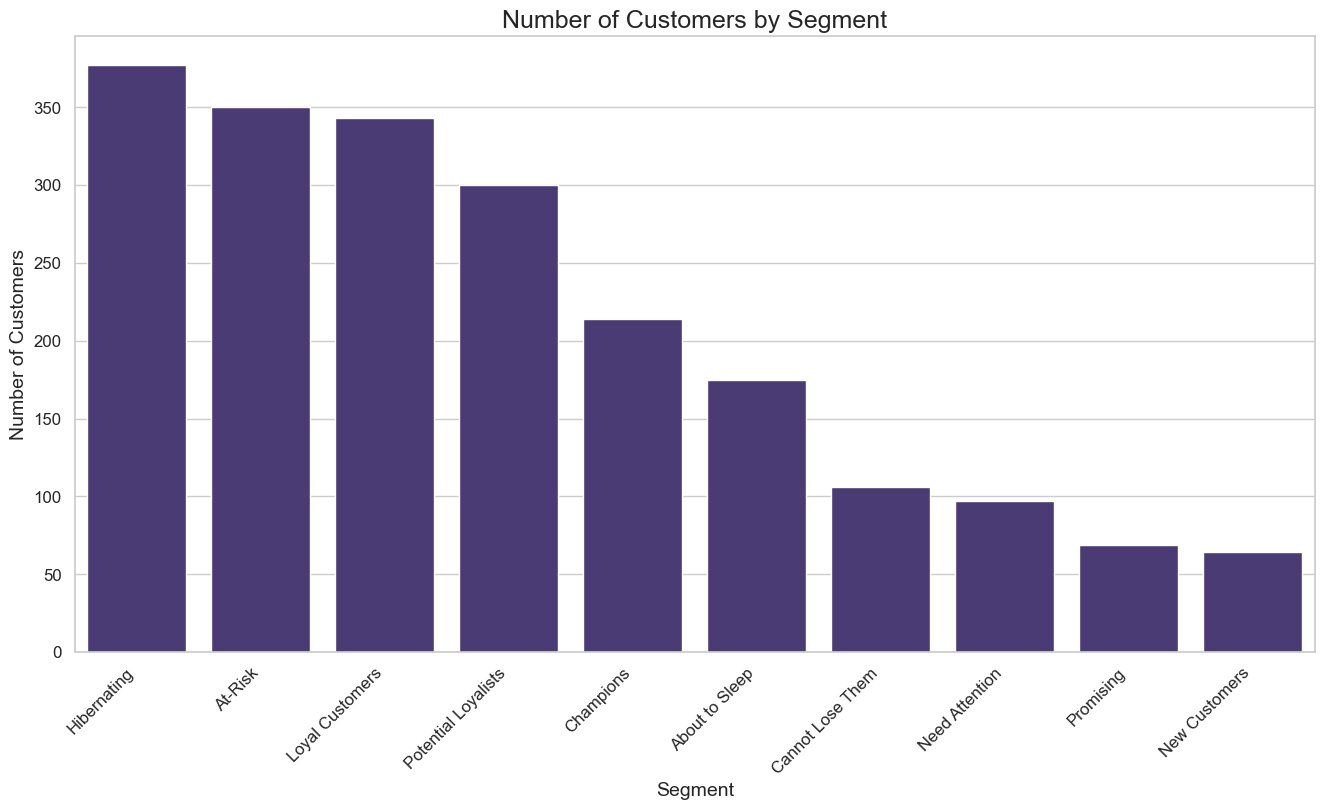

In [3]:
plt.figure(figsize=(16, 8))
sns.barplot(x=segment_profile.index, y=segment_profile['Count'], order=segment_profile.index)
plt.title('Number of Customers by Segment', fontsize=18)
plt.xlabel('Segment', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

In [4]:
plt.savefig('../reports/figures/number_of_customers_per_segment.png')

<Figure size 1400x700 with 0 Axes>

## Recommended Strategies

Based on my analysis of the segment profiles, I have formulated the following strategies:

* **Champions (214 customers):** I found that these are our best customers, with the highest average spend (£1928.8) and very recent purchases (avg. 32.5 days).

    * **Recommendation:** We should reward them with a VIP program, grant early access to new products, and send personalized thank-you notes. As they are likely brand advocates, I also suggest we encourage them to write reviews.

* **Loyal Customers (343 customers):** I identified this group as highly valuable, with a high average spend (£1598.4) and good purchase frequency.

    * **Recommendation:** My focus here would be on up-selling and cross-selling. I recommend we show them related products based on their purchase history and offer loyalty points or exclusive bundles.

* **Cannot Lose Them (106 customers):** I noticed they have the highest purchase frequency (2.2) but haven't purchased recently (avg. 263 days). Their spending is high (£1509.9).

    * **Recommendation:** This is a high-priority group. I propose launching a "We Miss You" campaign with a compelling, personalized discount to win them back. It would also be wise to ask for feedback to understand why they've lapsed.

* **At-Risk (350 customers):** I see this is a large group that used to purchase with decent frequency but has a high recency score (avg. 283.9 days).

    * **Recommendation:** I suggest targeting them with re-engagement campaigns. We can offer limited-time promotions and highlight what's new since their last visit.

* **Hibernating (377 customers):** This is our largest segment, but my analysis shows they are lapsed customers with low frequency and the highest recency (avg. 287.9 days).

    * **Recommendation:** I advise using a low-cost re-engagement channel like email. We can send a newsletter with popular products or a small coupon. We shouldn't invest heavily, but we should try to reactivate them.

* **New Customers (64 customers):** These are our most recent buyers (avg. 31.2 days) but with only one purchase so far.

    * **Recommendation:** My goal for this segment is to encourage a second purchase. I believe we can achieve this by providing an excellent post-purchase experience, sending a follow-up email with usage tips, and offering a small discount on their next order.

##  Summary and Conclusion

Here is a summary of my key findings from the data:

* **Key Insight 1:** Our Largest Segments are Lapsed Customers. I discovered that our biggest customer groups are 'Hibernating' (377) and 'At-Risk' (350). This tells me that a significant portion of our customer base is not actively purchasing, and a major business focus should be on re-engagement.

* **Key Insight 2:** Champions Drive the Most Value. My analysis shows that while the 'Champions' segment is not the largest (214 customers), they generate the highest average revenue (£1928.8) per customer. I conclude that retaining this group is critical for profitability.

* **Key Insight 3:** High-Priority Recovery Opportunity. I've identified the 'Cannot Lose Them' segment as a crucial group to target. Despite not purchasing for a long time, they were our most frequent buyers. I believe a successful win-back campaign for these 106 customers could yield significant revenue.

* **Next Steps:** The insights from my analysis should be compiled into a final report or presentation for stakeholders. My key message would be to balance retention strategies for top-tier segments ('Champions', 'Loyal Customers') with targeted win-back campaigns for lapsed but valuable customers ('Cannot Lose Them', 'At-Risk').